In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

The goal of this project was to study the network structure and evolution of citation papers. The research topic I used was AI but can be anything really

In [2]:
import requests
import time
import json
import os
from tqdm import tqdm

import networkx as nx

In [3]:
BASE_URL = "https://api.openalex.org/works"

CONCEPT_ID = "C154945302"  # AI
YEARS = list(range(2015, 2021))
PAPERS_PER_YEAR = 200

SAVE_PATH = "/kaggle/working/papers.json"

In [4]:
#Query the openalex API to retrive AI research papers with their publication year and citations

def fetch_papers(year):
    params = {
        "filter": f"concepts.id:{CONCEPT_ID},publication_year:{year}",
        "sort": "cited_by_count:desc",
        "per-page": PAPERS_PER_YEAR
    }
    
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    return response.json()["results"]


# Load existing data if it exists (resume capability)
if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH, "r") as f:
        papers = json.load(f)
    print(f"Loaded {len(papers)} cached papers")
else:
    papers = {}


for year in YEARS:
    # Skip if already fetched
    if any(p["year"] == year for p in papers.values()):
        print(f"Skipping {year} (already fetched)")
        continue

    print(f"Fetching {year}...")
    
    try:
        results = fetch_papers(year)
        
        for paper in results:
            papers[paper["id"]] = {
                "year": paper["publication_year"],
                "cited_by_count": paper["cited_by_count"],
                "references": paper["referenced_works"]
            }
        
        # Save after EACH year (critical for Kaggle)
        with open(SAVE_PATH, "w") as f:
            json.dump(papers, f)
        
        time.sleep(1)
    
    except Exception as e:
        print(f"Error on {year}: {e}")
        break

print(f"Total papers collected: {len(papers)}")

Fetching 2015...
Fetching 2016...
Fetching 2017...
Fetching 2018...
Fetching 2019...
Fetching 2020...
Total papers collected: 1200


In [5]:
with open(SAVE_PATH, "r") as f:
    papers = json.load(f)

print("Loaded papers:", len(papers))

Loaded papers: 1200


In [6]:
node_ids = set(papers.keys())
edges = []

for pid, data in papers.items():
    for ref in data["references"]:
        if ref in node_ids:
            edges.append((pid, ref))

print("Edges:", len(edges))

Edges: 5654


In [7]:
G = nx.DiGraph()

G.add_nodes_from(node_ids)
G.add_edges_from(edges)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1200
Edges: 5654


In [8]:
in_degrees = [d for _, d in G.in_degree()]

print("Average in-degree:", sum(in_degrees)/len(in_degrees))
print("Max in-degree:", max(in_degrees))

Average in-degree: 4.711666666666667
Max in-degree: 246


In [9]:
with open("/kaggle/working/edges.json", "w") as f:
    json.dump(edges, f)

In [10]:
import pandas as pd

df_nodes = pd.DataFrame.from_dict(papers, orient="index")
df_edges = pd.DataFrame(edges, columns=["source", "target"])

# Network Analysis

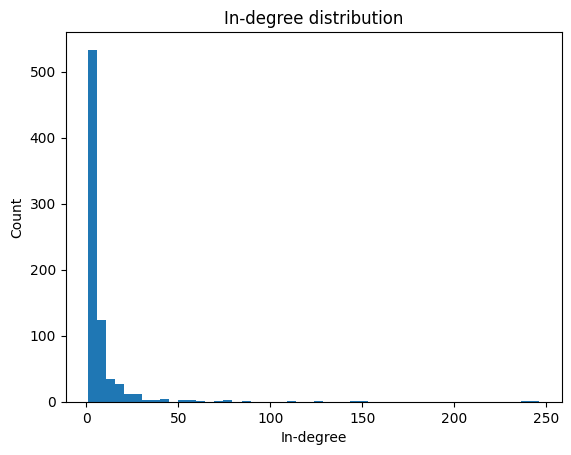

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#In degree is the amount of times a paper is cited by others in the network

in_degrees = np.array([d for _, d in G.in_degree()])

# Remove zeros for log plot
in_degrees = in_degrees[in_degrees > 0]

plt.figure()
plt.hist(in_degrees, bins=50)
plt.xlabel("In-degree")
plt.ylabel("Count")
plt.title("In-degree distribution")
plt.show()

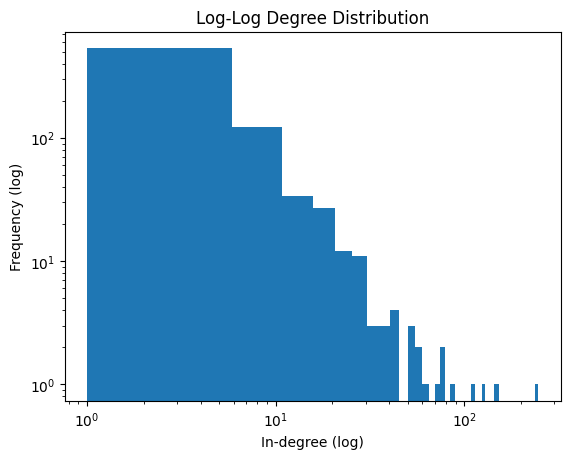

In [12]:
plt.figure()
plt.hist(in_degrees, bins=50, log=True)
plt.xscale("log")
plt.xlabel("In-degree (log)")
plt.ylabel("Frequency (log)")
plt.title("Log-Log Degree Distribution")
plt.show()

The network appears to be scale-free

In [13]:
#Get the page rank for top papers (pargerank assigns higher values to influencial sources)

pagerank = nx.pagerank(G, alpha=0.85)

# Top 10 papers
top_papers = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]

for pid, score in top_papers:
    print(pid, score)

https://openalex.org/W2163605009 0.25296684919072393
https://openalex.org/W2097117768 0.23400656785135598
https://openalex.org/W2117539524 0.015073286862779704
https://openalex.org/W1677182931 0.011597191385873337
https://openalex.org/W1903029394 0.00945325439345809
https://openalex.org/W2194775991 0.009285318684455542
https://openalex.org/W1836465849 0.008046580727440984
https://openalex.org/W2919115771 0.006960754548360803
https://openalex.org/W2145339207 0.005754879216678271
https://openalex.org/W1536680647 0.005035179700213244


In [14]:

#A look at some of the top papers
for pid, score in top_papers:
    print("Score:", score)
    print("Year:", papers[pid]["year"])
    print("Citations:", papers[pid]["cited_by_count"])
    print("-----")

Score: 0.25296684919072393
Year: 2017
Citations: 75673
-----
Score: 0.23400656785135598
Year: 2015
Citations: 46611
-----
Score: 0.015073286862779704
Year: 2015
Citations: 39966
-----
Score: 0.011597191385873337
Year: 2015
Citations: 18666
-----
Score: 0.00945325439345809
Year: 2015
Citations: 36660
-----
Score: 0.009285318684455542
Year: 2016
Citations: 219609
-----
Score: 0.008046580727440984
Year: 2015
Citations: 24333
-----
Score: 0.006960754548360803
Year: 2015
Citations: 80335
-----
Score: 0.005754879216678271
Year: 2015
Citations: 29529
-----
Score: 0.005035179700213244
Year: 2015
Citations: 27676
-----


In [15]:
#We use the louvain algorithm to detect communities

!pip install python-louvain

In [16]:
import community as community_louvain

# Convert to undirected (standard for Louvain)
G_undirected = G.to_undirected()

partition = community_louvain.best_partition(G_undirected)

# partition = {node_id: community_id}

In [17]:
from collections import Counter

community_sizes = Counter(partition.values())

print("Number of communities:", len(community_sizes))
print("Largest communities:", community_sizes.most_common(10))

Number of communities: 255
Largest communities: [(64, 150), (11, 114), (8, 103), (12, 92), (2, 91), (6, 91), (24, 83), (25, 78), (20, 42), (15, 24)]


In [18]:
from collections import defaultdict

community_papers = defaultdict(list)

for pid, comm_id in partition.items():
    community_papers[comm_id].append(pid)

In [19]:
def top_in_community(comm_id, n=5):
    papers_in_comm = community_papers[comm_id]
    
    ranked = sorted(
        papers_in_comm,
        key=lambda pid: papers[pid]["cited_by_count"],
        reverse=True
    )
    
    return ranked[:n]


# Example
for pid in top_in_community(0):
    print(papers[pid]["year"], papers[pid]["cited_by_count"])

2015 2021


In [20]:
community_years = defaultdict(list)

for pid, comm_id in partition.items():
    community_years[comm_id].append(papers[pid]["year"])

In [21]:
# Get top 500 nodes by PageRank
top_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:500]

G_sub = G.subgraph(top_nodes)

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

pos = nx.spring_layout(G_sub, k=0.15, iterations=50)

<Figure size 1200x1200 with 0 Axes>

In [23]:
node_colors = [partition[n] for n in G_sub.nodes()]

In [24]:
node_sizes = [pagerank[n] * 50000 for n in G_sub.nodes()]

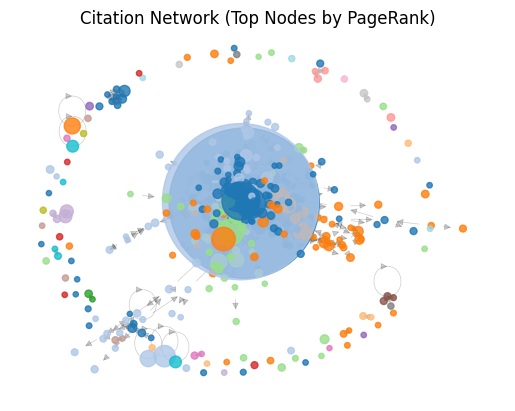

In [25]:
nx.draw_networkx_nodes(
    G_sub,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_sub,
    pos,
    alpha=0.2,
    width=0.5
)

plt.title("Citation Network (Top Nodes by PageRank)")
plt.axis("off")
plt.show()

{'https://openalex.org/W2163605009': Text(0.020901598485728128, 0.06286302024284385, 'https://openalex.org/W2163605009'),
 'https://openalex.org/W2097117768': Text(0.03707540332156608, 0.05505248158695145, 'https://openalex.org/W2097117768'),
 'https://openalex.org/W2117539524': Text(0.022859832742868166, 0.06684253821609543, 'https://openalex.org/W2117539524'),
 'https://openalex.org/W1677182931': Text(-0.008716552428700834, 0.07832353906874266, 'https://openalex.org/W1677182931'),
 'https://openalex.org/W1903029394': Text(0.027280483815620805, 0.09385991361768313, 'https://openalex.org/W1903029394'),
 'https://openalex.org/W2194775991': Text(0.06583494397703017, 0.053733887097653296, 'https://openalex.org/W2194775991'),
 'https://openalex.org/W1836465849': Text(0.010749394309670153, 0.08265955327745615, 'https://openalex.org/W1836465849'),
 'https://openalex.org/W2919115771': Text(-0.022863249983573624, -0.09743307784998284, 'https://openalex.org/W2919115771'),
 'https://openalex.org

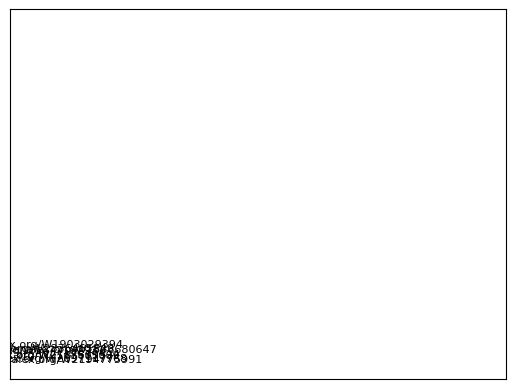

In [26]:
labels = {n: n for n in top_nodes[:10]}

nx.draw_networkx_labels(G_sub, pos, labels, font_size=8)

In [27]:
pos = nx.spring_layout(G_sub, k=0.3)

In [28]:
nx.write_gexf(G, "/kaggle/working/network.gexf")

In [29]:
#Are core nodes more connected?
core_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:100]

avg_degree_core = sum(dict(G.degree(core_nodes)).values()) / len(core_nodes)
avg_degree_all = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Core avg degree:", avg_degree_core)
print("Overall avg degree:", avg_degree_all)

Core avg degree: 34.47
Overall avg degree: 9.423333333333334


In [30]:
from collections import Counter
print(Counter(partition.values()))

Counter({64: 150, 11: 114, 8: 103, 12: 92, 2: 91, 6: 91, 24: 83, 25: 78, 20: 42, 15: 24, 21: 12, 1: 8, 7: 8, 32: 5, 80: 5, 3: 4, 36: 4, 73: 4, 101: 4, 120: 4, 139: 4, 195: 4, 31: 3, 44: 3, 65: 3, 83: 3, 90: 3, 91: 3, 100: 3, 116: 3, 164: 3, 207: 3, 39: 2, 42: 2, 74: 2, 121: 2, 128: 2, 132: 2, 150: 2, 152: 2, 153: 2, 165: 2, 179: 2, 181: 2, 214: 2, 5: 1, 9: 1, 10: 1, 14: 1, 16: 1, 18: 1, 19: 1, 22: 1, 23: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 33: 1, 34: 1, 35: 1, 37: 1, 38: 1, 40: 1, 43: 1, 45: 1, 46: 1, 47: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 75: 1, 77: 1, 78: 1, 79: 1, 81: 1, 82: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 117: 1, 118: 1, 119: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 129: 1

In [31]:
betweenness = nx.betweenness_centrality(G_sub)

top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

for pid, score in top_bridges:
    print(pid, score)

https://openalex.org/W2194775991 0.004624631877538647
https://openalex.org/W1514535095 0.0036752476248939027
https://openalex.org/W1536680647 0.0033675368795733547
https://openalex.org/W2919115771 0.0032472307108929763
https://openalex.org/W639708223 0.0027247588060478893
https://openalex.org/W2183182206 0.0026130932608797977
https://openalex.org/W1677182931 0.002185260749075125
https://openalex.org/W854541894 0.002022113038120957
https://openalex.org/W1895577753 0.001982627377996426
https://openalex.org/W2412782625 0.0016884718705351466


In [32]:
time_slices = [2016, 2017, 2018, 2019, 2020]

In [33]:
def build_graph_up_to_year(year, papers):
    nodes = [pid for pid, data in papers.items() if data["year"] <= year]
    node_set = set(nodes)
    
    edges = []
    for pid in nodes:
        for ref in papers[pid]["references"]:
            if ref in node_set:
                edges.append((pid, ref))
    
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    
    return G

In [34]:
results = []

for year in time_slices:
    G_t = build_graph_up_to_year(year, papers)
    
    num_nodes = G_t.number_of_nodes()
    num_edges = G_t.number_of_edges()
    
    avg_degree = sum(dict(G_t.degree()).values()) / num_nodes
    
    results.append({
        "year": year,
        "nodes": num_nodes,
        "edges": num_edges,
        "avg_degree": avg_degree
    })

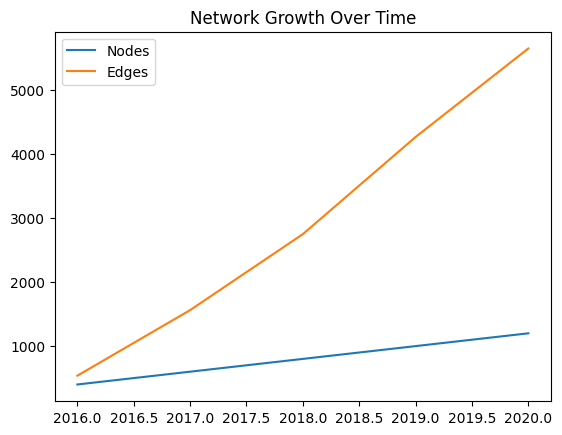

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

plt.figure()
plt.plot(df["year"], df["nodes"], label="Nodes")
plt.plot(df["year"], df["edges"], label="Edges")
plt.legend()
plt.title("Network Growth Over Time")
plt.show()

In [36]:
import community as community_louvain

community_counts = []

for year in time_slices:
    G_t = build_graph_up_to_year(year, papers)
    
    G_u = G_t.to_undirected()
    partition_t = community_louvain.best_partition(G_u)
    
    num_communities = len(set(partition_t.values()))
    
    community_counts.append((year, num_communities))

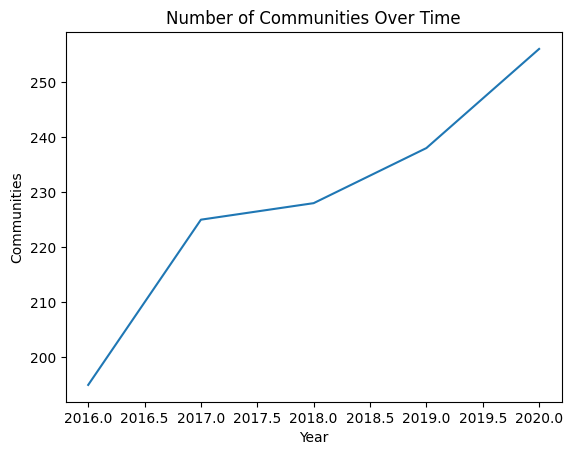

In [37]:
years, counts = zip(*community_counts)

plt.figure()
plt.plot(years, counts)
plt.title("Number of Communities Over Time")
plt.xlabel("Year")
plt.ylabel("Communities")
plt.show()

In [38]:
years_to_plot = [2016, 2018, 2020]

In [39]:
top_nodes_over_time = {}

for year in time_slices:
    G_t = build_graph_up_to_year(year, papers)
    pr = nx.pagerank(G_t)
    
    top_nodes = sorted(pr, key=pr.get, reverse=True)[:5]
    top_nodes_over_time[year] = top_nodes

In [40]:
print(top_nodes_over_time)

{2016: ['https://openalex.org/W2097117768', 'https://openalex.org/W2117539524', 'https://openalex.org/W1677182931', 'https://openalex.org/W1903029394', 'https://openalex.org/W1836465849'], 2017: ['https://openalex.org/W2163605009', 'https://openalex.org/W2097117768', 'https://openalex.org/W2117539524', 'https://openalex.org/W1677182931', 'https://openalex.org/W1903029394'], 2018: ['https://openalex.org/W2163605009', 'https://openalex.org/W2097117768', 'https://openalex.org/W2117539524', 'https://openalex.org/W1677182931', 'https://openalex.org/W1903029394'], 2019: ['https://openalex.org/W2163605009', 'https://openalex.org/W2097117768', 'https://openalex.org/W2117539524', 'https://openalex.org/W1677182931', 'https://openalex.org/W1903029394'], 2020: ['https://openalex.org/W2163605009', 'https://openalex.org/W2097117768', 'https://openalex.org/W2117539524', 'https://openalex.org/W1677182931', 'https://openalex.org/W1903029394']}


In [41]:
df["edge_node_ratio"] = df["edges"] / df["nodes"]

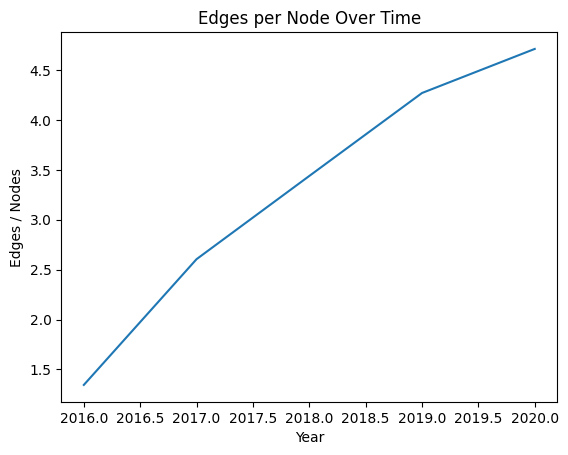

In [42]:
plt.figure()
plt.plot(df["year"], df["edge_node_ratio"])
plt.title("Edges per Node Over Time")
plt.xlabel("Year")
plt.ylabel("Edges / Nodes")
plt.show()

#Network is densifying

In [43]:
from collections import Counter

for year in time_slices:
    G_t = build_graph_up_to_year(year, papers)
    partition_t = community_louvain.best_partition(G_t.to_undirected())
    
    sizes = Counter(partition_t.values())
    print(year, sorted(sizes.values(), reverse=True)[:5])

2016 [37, 36, 33, 23, 18]
2017 [70, 62, 59, 50, 44]
2018 [138, 72, 65, 63, 59]
2019 [98, 89, 85, 78, 70]
2020 [132, 123, 99, 91, 86]


In [44]:
#Now we look at modularity,which measures how separated communities are

import community as community_louvain

modularity_results = []

for year in time_slices:
    G_t = build_graph_up_to_year(year, papers)
    
    # Convert to undirected for Louvain
    G_u = G_t.to_undirected()
    
    # Compute partition
    partition_t = community_louvain.best_partition(G_u)
    
    # Compute modularity
    mod_score = community_louvain.modularity(partition_t, G_u)
    
    modularity_results.append({
        "year": year,
        "modularity": mod_score
    })

In [45]:
import pandas as pd

mod_df = pd.DataFrame(modularity_results)
print(mod_df)

   year  modularity
0  2016    0.520728
1  2017    0.433989
2  2018    0.458414
3  2019    0.467035
4  2020    0.473297


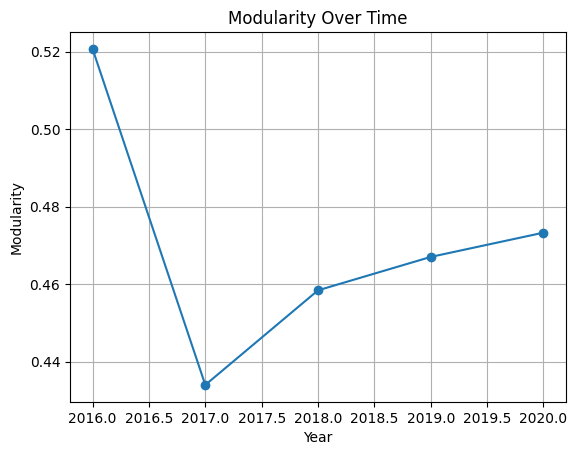

In [46]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(mod_df["year"], mod_df["modularity"], marker='o')
plt.title("Modularity Over Time")
plt.xlabel("Year")
plt.ylabel("Modularity")
plt.grid(True)
plt.show()

This is a very interesting structural change. Modularity decreased until 2017 then increased after. Later we will associate this with the widespread adoption of deep learning, often termed "the year of AI".

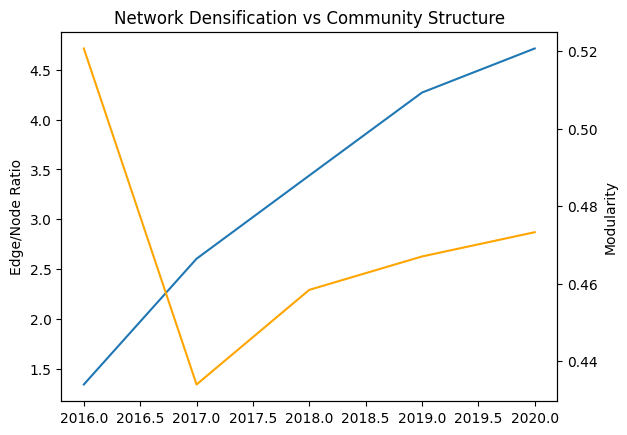

In [47]:
fig, ax1 = plt.subplots()

ax1.plot(df["year"], df["edge_node_ratio"], label="Edge/Node Ratio")
ax1.set_ylabel("Edge/Node Ratio")

ax2 = ax1.twinx()
ax2.plot(mod_df["year"], mod_df["modularity"], color='orange', label="Modularity")
ax2.set_ylabel("Modularity")

plt.title("Network Densification vs Community Structure")
plt.show()

In [48]:
def cross_community_ratio(G, partition):
    cross_edges = 0
    total_edges = G.number_of_edges()
    
    for u, v in G.edges():
        if partition[u] != partition[v]:
            cross_edges += 1
    
    return cross_edges / total_edges

In [49]:
from collections import Counter

def avg_community_size(partition):
    sizes = Counter(partition.values())
    return sum(sizes.values()) / len(sizes)

In [50]:
G_pre = build_graph_up_to_year(2016, papers)
G_post = build_graph_up_to_year(2020, papers)

In [51]:
import community as community_louvain

part_pre = community_louvain.best_partition(G_pre.to_undirected())
part_post = community_louvain.best_partition(G_post.to_undirected())

In [52]:
from collections import Counter

def summarize_partition(partition):
    sizes = Counter(partition.values())
    return {
        "num_communities": len(sizes),
        "largest": max(sizes.values()),
        "top5": sorted(sizes.values(), reverse=True)[:5]
    }

print("Pre-2017:", summarize_partition(part_pre))
print("Post-2017:", summarize_partition(part_post))

Pre-2017: {'num_communities': 191, 'largest': 35, 'top5': [35, 34, 33, 28, 25]}
Post-2017: {'num_communities': 256, 'largest': 156, 'top5': [156, 139, 105, 103, 98]}


In [53]:
def cross_community_ratio(G, partition):
    cross_edges = 0
    total_edges = G.number_of_edges()
    
    for u, v in G.edges():
        if partition[u] != partition[v]:
            cross_edges += 1
    
    return cross_edges / total_edges

print("Pre cross ratio:", cross_community_ratio(G_pre, part_pre))
print("Post cross ratio:", cross_community_ratio(G_post, part_post))

Pre cross ratio: 0.3252788104089219
Post cross ratio: 0.3604527767951892


In [54]:
def visualize_graph(G, partition, pagerank, title):
    top_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:400]
    G_sub = G.subgraph(top_nodes)
    
    pos = nx.spring_layout(G_sub, k=0.2)
    
    node_colors = [partition[n] for n in G_sub.nodes()]
    node_sizes = [pagerank[n] * 50000 for n in G_sub.nodes()]
    
    plt.figure(figsize=(8, 8))
    
    nx.draw_networkx_nodes(G_sub, pos,
                           node_size=node_sizes,
                           node_color=node_colors,
                           cmap=plt.cm.tab20,
                           alpha=0.8)
    
    nx.draw_networkx_edges(G_sub, pos, alpha=0.2)
    
    plt.title(title)
    plt.axis("off")
    plt.show()

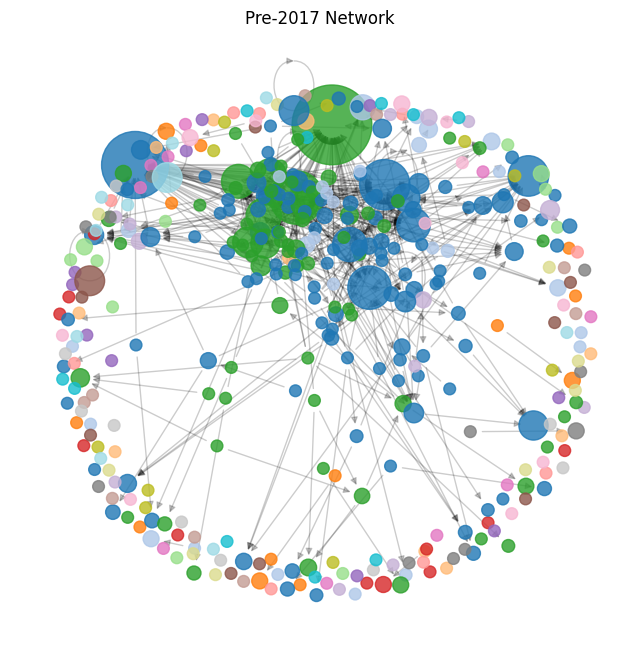

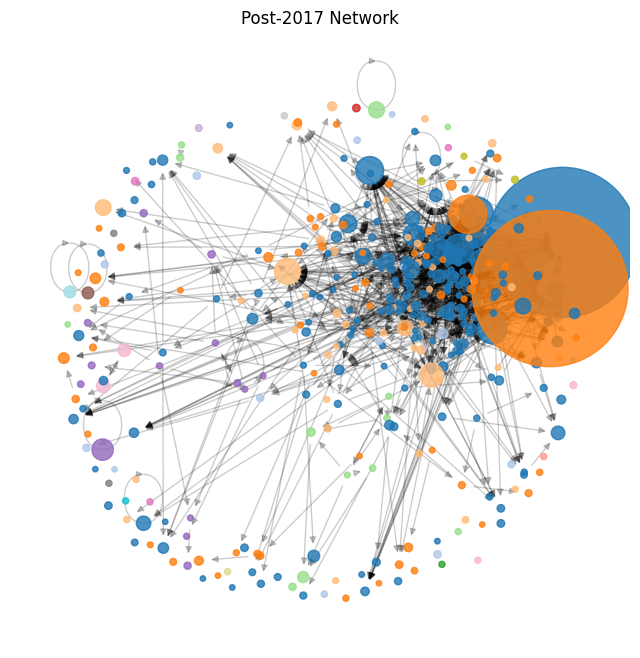

In [55]:
pr_pre = nx.pagerank(G_pre)
pr_post = nx.pagerank(G_post)

visualize_graph(G_pre, part_pre, pr_pre, "Pre-2017 Network")
visualize_graph(G_post, part_post, pr_post, "Post-2017 Network")

In [56]:
#We want to extract communities

from collections import defaultdict

def get_top_papers_by_community(partition, papers, n=5):
    comm_dict = defaultdict(list)
    
    for pid, comm in partition.items():
        comm_dict[comm].append(pid)
    
    top_per_comm = {}
    
    for comm, pids in comm_dict.items():
        ranked = sorted(
            pids,
            key=lambda pid: papers[pid]["cited_by_count"],
            reverse=True
        )
        top_per_comm[comm] = ranked[:n]
    
    return top_per_comm

In [57]:
top_pre = get_top_papers_by_community(part_pre, papers)
top_post = get_top_papers_by_community(part_post, papers)

In [58]:
print(top_pre)

{0: ['https://openalex.org/W1901129140', 'https://openalex.org/W639708223', 'https://openalex.org/W1903029394', 'https://openalex.org/W1536680647', 'https://openalex.org/W2193145675'], 1: ['https://openalex.org/W2919115771', 'https://openalex.org/W2145339207', 'https://openalex.org/W2257979135', 'https://openalex.org/W2271840356', 'https://openalex.org/W1901616594'], 44: ['https://openalex.org/W2194775991', 'https://openalex.org/W2097117768', 'https://openalex.org/W2183341477', 'https://openalex.org/W1677182931', 'https://openalex.org/W2302255633'], 3: ['https://openalex.org/W2117539524', 'https://openalex.org/W2295107390', 'https://openalex.org/W2331128040', 'https://openalex.org/W2963684088', 'https://openalex.org/W2557738935'], 4: ['https://openalex.org/W2102278945'], 5: ['https://openalex.org/W1836465849', 'https://openalex.org/W1885185971', 'https://openalex.org/W1522734439', 'https://openalex.org/W2557283755', 'https://openalex.org/W2242218935'], 6: ['https://openalex.org/W255965

In [59]:
def largest_communities(partition, k=5):
    from collections import Counter
    sizes = Counter(partition.values())
    return sorted(sizes.values(), reverse=True)[:k]

print("Pre:", largest_communities(part_pre))
print("Post:", largest_communities(part_post))

Pre: [35, 34, 33, 28, 25]
Post: [156, 139, 105, 103, 98]


In [60]:
def top_k_fraction(partition, k=2):
    from collections import Counter
    sizes = Counter(partition.values())
    top_k = sorted(sizes.values(), reverse=True)[:k]
    return sum(top_k) / sum(sizes.values())

print("Pre top-2 fraction:", top_k_fraction(part_pre))
print("Post top-2 fraction:", top_k_fraction(part_post))

Pre top-2 fraction: 0.1725
Post top-2 fraction: 0.24583333333333332


In [61]:
from collections import Counter

sizes = Counter(part_post.values())

# Get the two largest community IDs
top_two_comms = [comm for comm, _ in sizes.most_common(2)]

print("Top communities:", top_two_comms)

Top communities: [2, 42]


In [62]:
def get_community_papers(partition, target_comm):
    return [pid for pid, comm in partition.items() if comm == target_comm]

comm1_papers = get_community_papers(part_post, top_two_comms[0])
comm2_papers = get_community_papers(part_post, top_two_comms[1])

In [63]:
def top_papers(paper_ids, papers, n=10):
    return sorted(
        paper_ids,
        key=lambda pid: papers[pid]["cited_by_count"],
        reverse=True
    )[:n]

top_comm1 = top_papers(comm1_papers, papers)
top_comm2 = top_papers(comm2_papers, papers)

In [64]:
import requests

def fetch_title(paper_id):
    url = f"https://api.openalex.org/works/{paper_id.split('/')[-1]}"
    r = requests.get(url)
    return r.json().get("title", "N/A")

In [65]:
def print_top_with_titles(top_list):
    for pid in top_list:
        title = fetch_title(pid)
        print(title)
        print("Citations:", papers[pid]["cited_by_count"])
        print("-----")

print("Community 1:")
print_top_with_titles(top_comm1)

print("\nCommunity 2:")
print_top_with_titles(top_comm2)

Community 1:
Deep Residual Learning for Image Recognition
Citations: 219609
-----
Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks
Citations: 53541
-----
Going deeper with convolutions
Citations: 46611
-----
Densely Connected Convolutional Networks
Citations: 44135
-----
Fully convolutional networks for semantic segmentation
Citations: 36660
-----
Rethinking the Inception Architecture for Computer Vision
Citations: 30684
-----
Mask R-CNN
Citations: 28520
-----
Feature Pyramid Networks for Object Detection
Citations: 28321
-----
Squeeze-and-Excitation Networks
Citations: 27805
-----
Fast R-CNN
Citations: 27676
-----

Community 2:
Deep learning
Citations: 80335
-----
Human-level control through deep reinforcement learning
Citations: 29529
-----
Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations
Citations: 15783
-----
Mastering the game of Go with deep neural 

In [66]:
def get_titles(paper_ids, max_n=100):
    titles = []
    for pid in paper_ids[:max_n]:
        titles.append(fetch_title(pid).lower())
    return titles

titles_comm1 = get_titles(comm1_papers, 100)
titles_comm2 = get_titles(comm2_papers, 100)

In [67]:
from collections import Counter

keywords = [
    "reinforcement", "policy", "agent", "environment",
    "convolutional", "cnn", "image", "vision",
    "neural", "deep", "network",
    "learning", "training",
    "transformer", "attention"
]

In [68]:
def keyword_freq(titles, keywords):
    counts = Counter()
    for title in titles:
        for kw in keywords:
            if kw in title:
                counts[kw] += 1
    return counts

freq1 = keyword_freq(titles_comm1, keywords)
freq2 = keyword_freq(titles_comm2, keywords)

print("Community 1:", freq1)
print("Community 2:", freq2)

Community 1: Counter({'network': 41, 'deep': 26, 'convolutional': 23, 'image': 17, 'neural': 17, 'learning': 16, 'cnn': 8, 'vision': 3, 'attention': 2, 'training': 1, 'reinforcement': 1})
Community 2: Counter({'learning': 49, 'deep': 41, 'network': 32, 'neural': 27, 'convolutional': 10, 'reinforcement': 9, 'training': 5, 'policy': 3, 'image': 3, 'cnn': 1})


In [69]:
import re

def top_words(titles, n=20):
    words = []
    for title in titles:
        words += re.findall(r'\b[a-z]+\b', title)
    
    return Counter(words).most_common(n)

print("Top words community 1:", top_words(titles_comm1))
print("Top words community 2:", top_words(titles_comm2))

Top words community 1: [('for', 38), ('networks', 30), ('deep', 24), ('convolutional', 23), ('and', 22), ('neural', 17), ('with', 16), ('learning', 16), ('a', 14), ('image', 13), ('network', 12), ('detection', 12), ('segmentation', 11), ('object', 11), ('of', 11), ('semantic', 10), ('in', 10), ('residual', 9), ('r', 8), ('classification', 8)]
Top words community 2: [('learning', 50), ('deep', 41), ('a', 36), ('for', 33), ('and', 31), ('neural', 28), ('networks', 24), ('of', 21), ('with', 19), ('machine', 16), ('based', 12), ('the', 11), ('in', 11), ('data', 11), ('network', 10), ('convolutional', 10), ('reinforcement', 9), ('survey', 9), ('using', 7), ('applications', 6)]


#“Post-2017, the AI citation network becomes dominated by two major communities. One corresponds to general deep learning methods, including reinforcement learning and classification tasks, while the other is strongly centered on computer vision, particularly image segmentation and convolutional architectures. This suggests that the field has reorganized into a methodological core alongside major application domains.”